<a href="https://colab.research.google.com/github/MridulSharma02/Deep-Learning-2025-26-Mridul-Sharma/blob/main/DL_Experiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Path to dataset files: /kaggle/input/mnist-in-csv


In [ ]:
import os
# List all files in the downloaded directory to find the actual CSV file name.
files_in_path = os.listdir(path)
# Assuming there's one main CSV file, or we need to find a specific one like 'mnist-in-csv.csv'
csv_file_name = None
for f in files_in_path:
    if f.endswith('.csv'):
        csv_file_name = f
        break
if csv_file_name:
    full_csv_path = os.path.join(path, csv_file_name)
    data = pd.read_csv(full_csv_path)
    print("Top 10 Rows of Dataset:")
    print(data.head(10))
    # Separate features and label
    X = data.iloc[:, 1:].values   # pixels
    y = data.iloc[:, 0].values    # digit label
else:
    print(f"Error: No CSV file found in the directory: {path}")

Top 10 Rows of Dataset:
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      7    0    0    0    0    0    0    0    0    0  ...      0      0   
1      2    0    0    0    0    0    0    0    0    0  ...      0      0   
2      1    0    0    0    0    0    0    0    0    0  ...      0      0   
3      0    0    0    0    0    0    0    0    0    0  ...      0      0   
4      4    0    0    0    0    0    0    0    0    0  ...      0      0   
5      1    0    0    0    0    0    0    0    0    0  ...      0      0   
6      4    0    0    0    0    0    0    0    0    0  ...      0      0   
7      9    0    0    0    0    0    0    0    0    0  ...      0      0   
8      5    0    0    0    0    0    0    0    0    0  ...      0      0   
9      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0    

In [ ]:
# Normalize pixel values (0–255 → 0–1)
X = X / 255.0
# Reshape into 28x28x1 (for CNN)
X = X.reshape(-1, 28, 28, 1)
# One-hot encode labels
y = to_categorical(y, 10)
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Accuracy:", round(accuracy*100,2), "%")

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.6000 - loss: 1.4293 - val_accuracy: 0.9262 - val_loss: 0.3086
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9224 - loss: 0.2541 - val_accuracy: 0.9538 - val_loss: 0.1685
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9613 - loss: 0.1213 - val_accuracy: 0.9650 - val_loss: 0.1214
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9709 - loss: 0.1022 - val_accuracy: 0.9750 - val_loss: 0.0894
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9803 - loss: 0.0644 - val_accuracy: 0.9588 - val_loss: 0.1203
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9821 - loss: 0.0607 - val_accuracy: 0.9800 - val_loss: 0.0697
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.9874 - loss: 0.0435 - val_accuracy: 0.9762 - val_loss: 0.1006
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9885 - loss: 0.0359 - val_accuracy: 0.9812 -

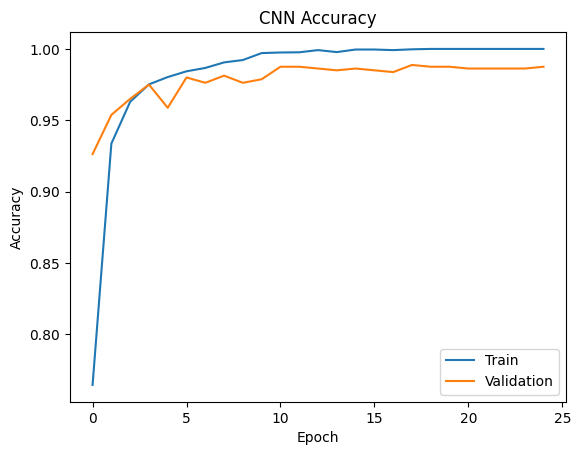

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

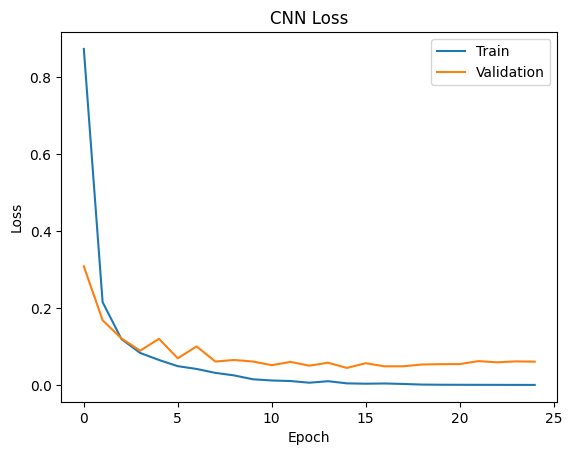

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

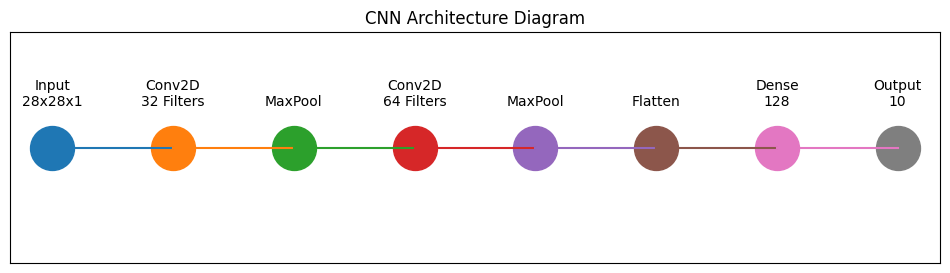

In [ ]:
plt.figure(figsize=(12,3))
layers = [
    ("Input\n28x28x1", 0),
    ("Conv2D\n32 Filters", 1),
    ("MaxPool", 2),
    ("Conv2D\n64 Filters", 3),
    ("MaxPool", 4),
    ("Flatten", 5),
    ("Dense\n128", 6),
    ("Output\n10", 7)
]
for name, pos in layers:
    plt.scatter(pos, 1, s=1000)
    plt.text(pos, 1.02, name, ha='center')
for i in range(len(layers)-1):
    plt.plot([layers[i][1], layers[i+1][1]], [1,1])
plt.yticks([])
plt.xticks([])
plt.title("CNN Architecture Diagram")
plt.show()